# Monthly topic distributions for `btw25`

With our data from lanz-mining, we can use jupyter to build some simple scripts and explore the obtained data. 
Further we can show the background and make the process a little more transparent (at least for people with some coding knowledge).

Here we analyse the last two years as of January 2025. So our data will range from Jan. 2023 to (including) Jan. 2025. Our goal ist to classify scraped descriptions texts from episodes and guests (when available). 

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from datetime import date

from lanz_mining.dataproc import text
from lanz_mining.projects.utils import get_all_basic_frames, df_to_time_range

In [2]:
# We exclude journalism (it's just an escape topic for our zero-shot inference model)
SELECTED_TOPICS = [t for t in text.TOPICS if t != "Journalismus"]
SELECTED_TOPICS

['Außenpolitik',
 'Innenpolitik',
 'Sicherheit',
 'Energie',
 'Gesundheit',
 'Digitales',
 'Russland',
 'Ukraine',
 'Nahost',
 'Migration',
 'Wirtschaft',
 'Klima',
 'Bildung',
 'Rechtliches',
 'Soziales']

In [3]:
SELECTED_TOPICS = [t for t in text.TOPICS if t != "Journalismus"]
lanz_df, illner_df, miosga_df = get_all_basic_frames(["date", "name", "talkshow", *SELECTED_TOPICS], "../../")

lanz_df.shape, illner_df.shape, miosga_df.shape

((1358, 19), (190, 19), (100, 19))

In [4]:
lanz_df.head(3)

episode_name,date,name,talkshow,Außenpolitik,Innenpolitik,Sicherheit,Energie,Gesundheit,Digitales,Russland,Ukraine,Nahost,Migration,Wirtschaft,Klima,Bildung,Rechtliches,Soziales
str,datetime[μs],str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""Markus Lanz vom 9. Januar 2024""",2024-01-09 00:00:00,"""Anton Hofreiter""","""markuslanz""",0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
"""Markus Lanz vom 9. Januar 2024""",2024-01-09 00:00:00,"""Ursula Weidenfeld""","""markuslanz""",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
"""Markus Lanz vom 9. Januar 2024""",2024-01-09 00:00:00,"""Henrik Wendorff""","""markuslanz""",0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [19]:
all_contexts_df: pl.DataFrame = pl.concat([lanz_df, illner_df, miosga_df], how="vertical")
all_contexts_df = df_to_time_range(
    all_contexts_df, start=date(2023, 1, 1), end=date(2025, 2, 1)
)
all_contexts_df["date"].min(), all_contexts_df["date"].max()

(datetime.datetime(2023, 1, 11, 0, 0), datetime.datetime(2025, 1, 30, 0, 0))

In [20]:
# Create column ym as date type to summarize all optics in a month
# The actual date is the first of the month e.g. 2023-01-01 summarizes all topics of Jan. 2023

topics_by_date_df = all_contexts_df[*["date", *SELECTED_TOPICS]]
topics_by_date_df = topics_by_date_df.with_columns(
    pl.col("date")
    .map_elements(lambda d: date(d.year, d.month, 1), pl.Date)
    .alias("ym")
).sort("ym")

topics_by_date_df["ym"].min(), topics_by_date_df["ym"].max()

(datetime.date(2023, 1, 1), datetime.date(2025, 1, 1))

In [21]:
dated_df = topics_by_date_df.group_by("ym").agg(
    [pl.sum(col_name) for col_name in SELECTED_TOPICS]
)
dated_df = dated_df.with_row_index("id")
dated_df.head()

id,ym,Außenpolitik,Innenpolitik,Sicherheit,Energie,Gesundheit,Digitales,Russland,Ukraine,Nahost,Migration,Wirtschaft,Klima,Bildung,Rechtliches,Soziales
u32,date,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,2023-01-01,1,0,4,5,0,0,0,3,0,4,5,4,2,1,2
1,2023-02-01,9,1,5,0,3,0,3,7,1,4,1,0,0,6,2
2,2023-03-01,8,0,3,6,0,4,2,1,1,4,10,4,2,11,5
3,2023-04-01,3,0,3,6,1,3,0,1,0,1,9,7,0,5,2
4,2023-05-01,7,1,0,11,0,4,4,3,2,10,9,2,3,1,3


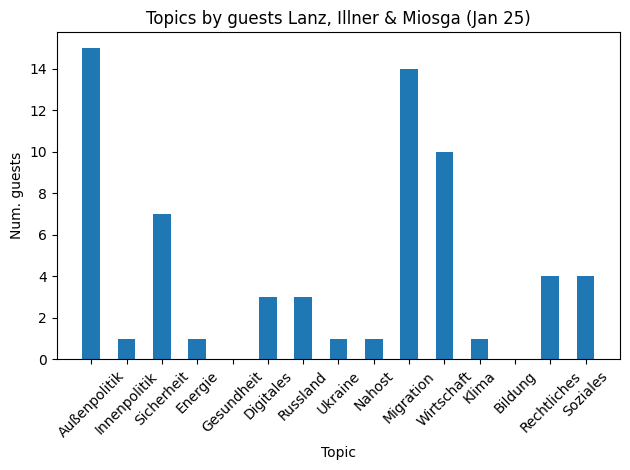

In [22]:
# Filter January 2025 row and plot it
selected_month = date(2025, 1, 1)
select_df = dated_df.filter(pl.col("ym") == selected_month)

dist_ids = range(0, len(SELECTED_TOPICS))
date_label = [d.strftime("%b %y") for d in select_df["ym"]][0]
plt.title(f"Topics by guests Lanz, Illner & Miosga ({date_label})")
plt.bar(dist_ids, select_df[*SELECTED_TOPICS].to_numpy()[0], width=0.5)
plt.xticks(dist_ids, labels=SELECTED_TOPICS, rotation=45)
plt.xlabel("Topic")
plt.ylabel("Num. guests")
plt.tight_layout()
plt.show()

Our main peaks are "Außenpolitik" (foreign politics), "Migration" (migration) and "Wirtschaft" (economy) for January 2025. There's a bit of "Soziales" (social) but only 4 people talk about it. Inbetween we have "Sicherheit" Security.

In [23]:
topic2color = {
    "Bildung": "#EC4899",
    "Energie": "#FACA15",
    "Klima": "#84CC16",
    "Migration": "#0EA5E9",
    "Wirtschaft": "#78716C",
}
x_labels = [d.strftime("%b %y") for d in dated_df["ym"]]
# Transform the data, so we can plot it as stacked bars
topic2sequence = {topic: dated_df[topic].to_numpy() for topic in topic2color.keys()}
topic2sequence

{'Bildung': array([2, 0, 2, 0, 3, 1, 0, 1, 0, 0, 0, 1, 3, 1, 0, 5, 1, 2, 1, 0, 1, 0,
        2, 3, 0]),
 'Energie': array([ 5,  0,  6,  6, 11, 11,  5,  3,  7,  1,  1,  1,  0,  4,  3,  2,  3,
         1,  1,  0,  4,  2,  1,  2,  1]),
 'Klima': array([ 4,  0,  4,  7,  2, 10,  2,  0,  4,  0,  0,  2,  2,  2,  0,  2,  2,
         1,  1,  0,  0,  0,  0,  1,  1]),
 'Migration': array([ 4,  4,  4,  1, 10,  2,  1,  2,  5, 16, 14,  4,  0,  0,  9,  6,  3,
         7,  2,  4, 16, 10,  2,  5, 14]),
 'Wirtschaft': array([ 5,  1, 10,  9,  9,  8,  4,  3,  8,  0,  5, 10, 10, 11, 13, 12,  4,
         2,  4,  0,  4, 15,  7,  8, 10])}

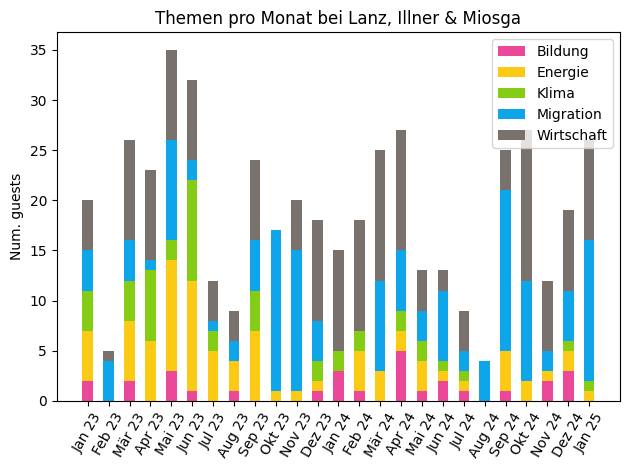

In [24]:
# Plot the selected topics for btw25
bar_start = np.zeros(len(x_labels))
width = 0.5
fig, ax = plt.subplots()
ax.set_title("Themen pro Monat bei Lanz, Illner & Miosga")
for topic, sequence in topic2sequence.items():
    ax.bar(x_labels, sequence, width, label=topic, bottom=bar_start, color=topic2color[topic])
    bar_start += sequence

ax.set_xticks(dated_df["id"].to_numpy(), labels=x_labels, rotation=60)
ax.set_ylabel("Num. guests")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [25]:
# Plot all topics in the same format
all_topic2sequence = {topic: dated_df[topic].to_numpy() for topic in SELECTED_TOPICS}
all_topic2sequence

{'Außenpolitik': array([ 1,  9,  8,  3,  7,  5,  2,  3,  2, 10,  7,  2,  5,  7,  9, 12, 15,
         3, 15,  1,  9, 16, 19,  2, 15]),
 'Innenpolitik': array([0, 1, 0, 0, 1, 0, 2, 1, 0, 0, 2, 0, 1, 0, 0, 9, 2, 1, 1, 2, 2, 0,
        0, 1, 1]),
 'Sicherheit': array([ 4,  5,  3,  3,  0,  5,  4,  0,  2,  7,  6,  4,  6,  8,  7, 11, 10,
         7, 15,  3,  5,  5,  5,  6,  7]),
 'Energie': array([ 5,  0,  6,  6, 11, 11,  5,  3,  7,  1,  1,  1,  0,  4,  3,  2,  3,
         1,  1,  0,  4,  2,  1,  2,  1]),
 'Gesundheit': array([0, 3, 0, 1, 0, 3, 0, 0, 0, 0, 2, 0, 0, 5, 1, 1, 3, 1, 0, 0, 1, 1,
        3, 0, 0]),
 'Digitales': array([0, 0, 4, 3, 4, 1, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 1, 4, 0, 0, 0, 2,
        0, 1, 3]),
 'Russland': array([ 0,  3,  2,  0,  4,  3,  2,  2,  5,  1,  1,  1,  2,  6, 10,  2,  7,
         2,  2,  0,  6,  3,  3,  2,  3]),
 'Ukraine': array([3, 7, 1, 1, 3, 3, 1, 2, 4, 2, 1, 2, 4, 4, 8, 6, 2, 3, 1, 0, 5, 2,
        2, 4, 1]),
 'Nahost': array([ 0,  1,  1,  0,  2,  0,  0,  0,

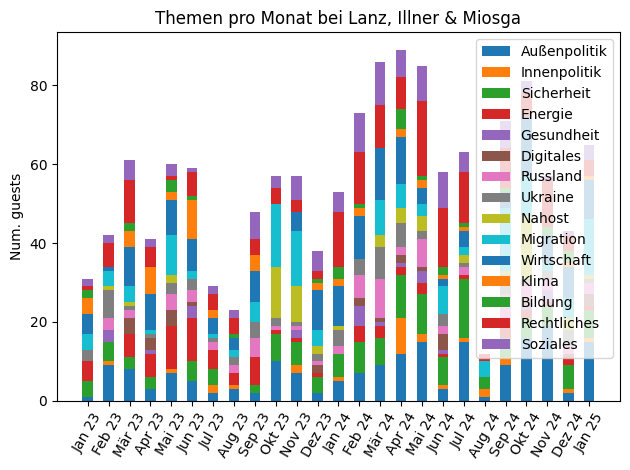

In [26]:
bar_start = np.zeros(len(x_labels))
width = 0.5
fig, ax = plt.subplots()
ax.set_title("Themen pro Monat bei Lanz, Illner & Miosga")
for topic, sequence in all_topic2sequence.items():
    ax.bar(x_labels, sequence, width, label=topic, bottom=bar_start)
    bar_start += sequence

ax.set_xticks(dated_df["id"].to_numpy(), labels=x_labels, rotation=60)
ax.set_ylabel("Num. guests")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [27]:
matrix = np.vstack([list(seq) for seq in all_topic2sequence.values()])
matrix.shape

(15, 25)

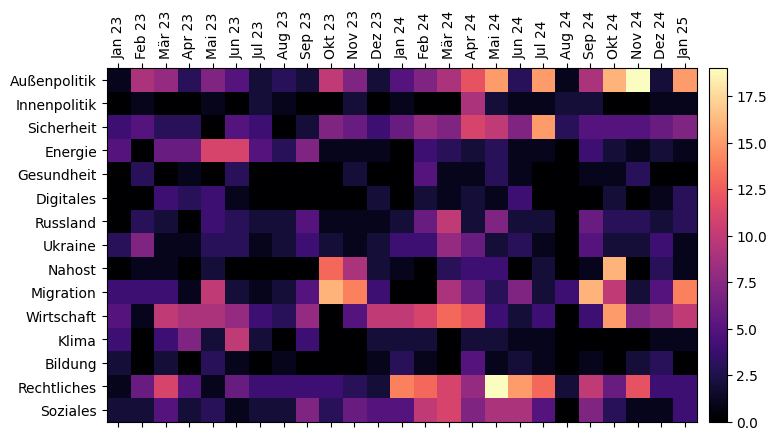

In [28]:
im = plt.matshow(matrix, cmap="magma")
plt.yticks(np.arange(matrix.shape[0]), labels=list(all_topic2sequence.keys()))
plt.xticks(np.arange(matrix.shape[1]), labels=x_labels, rotation=90)
plt.colorbar(im, fraction=0.0285, pad=0.02)
plt.show()